In [1]:
!pip install torch torchvision numpy matplotlib scikit-learn tqdm Pillow seaborn -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, jaccard_score
from tqdm import tqdm
import random
import os
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# ---- Global Config ----
NUM_CLASSES   = 6
IMG_SIZE      = 64
BATCH_SIZE    = 16
EPOCHS        = 25
LR            = 1e-3
NUM_TRAIN     = 400
NUM_VAL       = 100

CLASS_NAMES = ['Background', 'Vegetation', 'Building', 'Road', 'Water', 'Bare Soil']
CLASS_COLORS = np.array([
    [0,   0,   0  ],  # Background - Black
    [34,  139, 34 ],  # Vegetation - Forest Green
    [178, 34,  34 ],  # Building   - Firebrick
    [128, 128, 128],  # Road       - Gray
    [30,  144, 255],  # Water      - Dodger Blue
    [210, 180, 140],  # Bare Soil  - Tan
], dtype=np.uint8)

print(f'Classes: {CLASS_NAMES}')

Using device: cuda
PyTorch version: 2.10.0+cu128
Classes: ['Background', 'Vegetation', 'Building', 'Road', 'Water', 'Bare Soil']


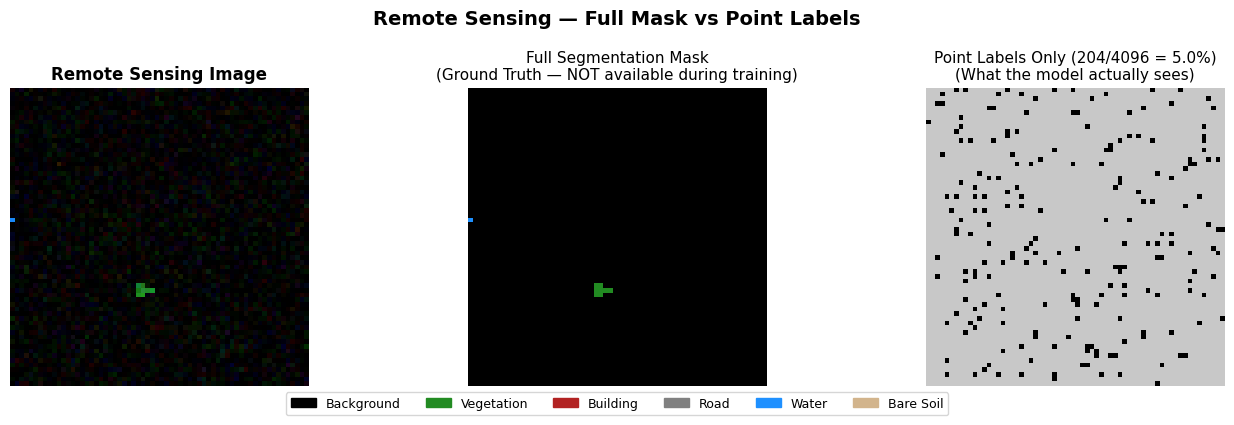

Saved: sample_visualisation.png


In [3]:
def generate_remote_sensing_patch(img_size=64, num_classes=6, seed=None):
    """Generate a synthetic remote sensing image and its segmentation mask."""
    if seed is not None:
        np.random.seed(seed)

    H, W = img_size, img_size
    mask = np.zeros((H, W), dtype=np.int64)

    num_blobs = np.random.randint(4, 10)
    for _ in range(num_blobs):
        cls = np.random.randint(0, num_classes)
        cy  = np.random.randint(0, H)
        cx  = np.random.randint(0, W)
        radius = np.random.randint(8, 30)
        Y, X = np.ogrid[:H, :W]
        dist = np.sqrt((Y - cy)**2 + (X - cx)**2)
        mask[dist < radius] = cls

    img = np.zeros((H, W, 3), dtype=np.float32)
    base_colors = CLASS_COLORS.astype(np.float32) / 255.0
    for c in range(num_classes):
        region = (mask == c)
        for ch in range(3):
            img[:, :, ch][region] = base_colors[c, ch]

    # Add realistic noise
    img += np.random.normal(0, 0.05, img.shape)
    img = np.clip(img, 0, 1)

    return img, mask


def simulate_point_labels(mask, point_density=0.05):
    """
    Randomly sample point labels from full mask.
    Returns point_mask: same shape as mask, -1 = unlabeled, >=0 = labeled class.
    """
    H, W = mask.shape
    total_pixels = H * W
    num_points = max(1, int(total_pixels * point_density))

    point_mask = np.full((H, W), -1, dtype=np.int64)
    indices = np.random.choice(total_pixels, num_points, replace=False)
    rows, cols = np.unravel_index(indices, (H, W))
    point_mask[rows, cols] = mask[rows, cols]

    return point_mask


class RemoteSensingDataset(Dataset):
    """Synthetic remote sensing segmentation dataset with point labels."""
    def __init__(self, num_samples=400, img_size=64, point_density=0.05, augment=True):
        self.num_samples   = num_samples
        self.img_size      = img_size
        self.point_density = point_density
        self.augment       = augment
        self.normalize     = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

        self.data = [generate_remote_sensing_patch(img_size, NUM_CLASSES, seed=i)
                     for i in range(num_samples)]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, full_mask = self.data[idx]
        point_mask = simulate_point_labels(full_mask, self.point_density)

        # Augmentation
        if self.augment:
            if np.random.rand() > 0.5:
                img       = np.fliplr(img).copy()
                full_mask = np.fliplr(full_mask).copy()
                point_mask= np.fliplr(point_mask).copy()
            if np.random.rand() > 0.5:
                img       = np.flipud(img).copy()
                full_mask = np.flipud(full_mask).copy()
                point_mask= np.flipud(point_mask).copy()

        # To tensor
        img_t   = torch.from_numpy(img.transpose(2, 0, 1))  # C, H, W
        img_t   = self.normalize(img_t)
        mask_t  = torch.from_numpy(full_mask).long()
        point_t = torch.from_numpy(point_mask).long()

        return img_t, mask_t, point_t


def visualise_sample(img, full_mask, point_mask, title='Sample'):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(img)
    axes[0].set_title('Remote Sensing Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    seg_rgb = CLASS_COLORS[full_mask]
    axes[1].imshow(seg_rgb)
    axes[1].set_title('Full Segmentation Mask\n(Ground Truth — NOT available during training)', fontsize=11)
    axes[1].axis('off')

    # Show point labels
    point_vis = np.ones((*point_mask.shape, 3), dtype=np.uint8) * 200
    labeled = point_mask >= 0
    if labeled.any():
        point_vis[labeled] = CLASS_COLORS[point_mask[labeled]]
    axes[2].imshow(point_vis)
    labeled_count = labeled.sum()
    total = point_mask.size
    axes[2].set_title(f'Point Labels Only ({labeled_count}/{total} = {labeled_count/total*100:.1f}%)\n(What the model actually sees)', fontsize=11)
    axes[2].axis('off')

    patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_visualisation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: sample_visualisation.png')


img_sample, mask_sample = generate_remote_sensing_patch(IMG_SIZE, NUM_CLASSES, seed=0)
pt_sample = simulate_point_labels(mask_sample, point_density=0.05)
visualise_sample(img_sample, mask_sample, pt_sample, title='Remote Sensing — Full Mask vs Point Labels')

Partial Focal Cross-Entropy Loss

The key contribution: only compute loss at **labeled pixels** (point annotations).

$$pfCE = \frac{\sum_{i} FocalLoss(pred_i, GT_i) \cdot \mathbb{1}[point_i \geq 0]}{\sum_{i} \mathbb{1}[point_i \geq 0]}$$

When $\gamma = 0$: reduces to standard partial Cross-Entropy.

In [4]:
class PartialFocalCELoss(nn.Module):
    """
    Partial (Focal) Cross-Entropy Loss for point-supervised segmentation.

    Only pixels with valid point annotations contribute to the loss.
    Focal weighting down-weights easy examples: (1 - p_t)^gamma * log(p_t)

    Args:
        gamma (float): Focal loss exponent. 0 = standard CE.
        alpha (float): Class balance weight (optional).
        ignore_index (int): Label value for unlabeled pixels.
    """
    def __init__(self, gamma=2.0, alpha=None, ignore_index=-1, num_classes=6):
        super().__init__()
        self.gamma        = gamma
        self.ignore_index = ignore_index
        self.num_classes  = num_classes

        if alpha is not None:
            self.alpha = torch.tensor(alpha, dtype=torch.float32)
        else:
            self.alpha = None

    def forward(self, logits, point_mask):
        """
        Args:
            logits     : (B, C, H, W) — raw model outputs
            point_mask : (B, H, W)   — point labels; -1 = unlabeled
        Returns:
            scalar loss
        """
        B, C, H, W = logits.shape

        # Build binary mask for labeled pixels
        labeled_mask = (point_mask != self.ignore_index)  # (B, H, W)

        if labeled_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True, device=logits.device)

        # Replace ignore index with 0 so gather doesn't fail
        safe_labels = point_mask.clone()
        safe_labels[~labeled_mask] = 0

        # Softmax probabilities
        probs = F.softmax(logits, dim=1)                  # (B, C, H, W)

        # Gather probability of the true class at each pixel
        safe_labels_exp = safe_labels.unsqueeze(1)        # (B, 1, H, W)
        p_t = probs.gather(1, safe_labels_exp).squeeze(1) # (B, H, W)

        # Log probabilities (for numerical stability use log_softmax)
        log_probs     = F.log_softmax(logits, dim=1)
        log_p_t       = log_probs.gather(1, safe_labels_exp).squeeze(1)  # (B, H, W)

        # Focal weight: (1 - p_t)^gamma
        focal_weight  = (1.0 - p_t) ** self.gamma         # (B, H, W)

        # Element-wise focal CE loss
        pixel_loss    = -focal_weight * log_p_t            # (B, H, W)

        # Partial: only labeled pixels
        labeled_loss  = pixel_loss * labeled_mask.float()

        # Normalise by number of labeled pixels (as in paper)
        loss = labeled_loss.sum() / (labeled_mask.float().sum() + 1e-8)

        return loss


print('=== Loss Function Sanity Check ===')
_logits = torch.randn(2, NUM_CLASSES, IMG_SIZE, IMG_SIZE)
_labels = torch.randint(-1, NUM_CLASSES, (2, IMG_SIZE, IMG_SIZE))

for g in [0, 1, 2, 5]:
    loss_fn = PartialFocalCELoss(gamma=g)
    loss    = loss_fn(_logits, _labels)
    labeled_count = (_labels >= 0).sum().item()
    print(f'  gamma={g}: loss={loss.item():.4f}  (labeled pixels: {labeled_count}/{2*IMG_SIZE*IMG_SIZE})')

print('\n✓ All gamma values produce valid scalar losses')

=== Loss Function Sanity Check ===
  gamma=0: loss=2.1972  (labeled pixels: 6982/8192)
  gamma=1: loss=1.9549  (labeled pixels: 6982/8192)
  gamma=2: loss=1.7623  (labeled pixels: 6982/8192)
  gamma=5: loss=1.3583  (labeled pixels: 6982/8192)

✓ All gamma values produce valid scalar losses


U-Net Segmentation Model

We implement a configurable U-Net with optional pretrained ResNet encoder (transfer learning).

In [5]:
class DoubleConv(nn.Module):
    """Two conv-BN-ReLU blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Configurable U-Net for point-supervised segmentation.
    depth: 2 (shallow) or 3 (deep)
    """
    def __init__(self, in_channels=3, num_classes=6, depth=3, base_filters=32):
        super().__init__()
        self.depth = depth
        f = base_filters

        # Encoder
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f, f*2)
        self.pool = nn.MaxPool2d(2)

        if depth >= 3:
            self.enc3 = DoubleConv(f*2, f*4)
            self.bottleneck = DoubleConv(f*4, f*8)
            self.up3   = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
            self.dec3  = DoubleConv(f*8, f*4)
        else:
            self.bottleneck = DoubleConv(f*2, f*4)

        # Decoder
        self.up2 = nn.ConvTranspose2d(f*4 if depth >= 3 else f*4, f*2, 2, stride=2)
        self.dec2 = DoubleConv(f*4, f*2)
        self.up1  = nn.ConvTranspose2d(f*2, f, 2, stride=2)
        self.dec1 = DoubleConv(f*2, f)

        self.head = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        if self.depth >= 3:
            e3 = self.enc3(self.pool(e2))
            b  = self.bottleneck(self.pool(e3))
            d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
            d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        else:
            b  = self.bottleneck(self.pool(e2))
            d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))

        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

shallow = UNet(depth=2)
deep    = UNet(depth=3)
print(f'Shallow U-Net (depth=2): {count_params(shallow):,} parameters')
print(f'Deep    U-Net (depth=3): {count_params(deep):,} parameters')

x_dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
out     = deep(x_dummy)
print(f'Input shape:  {x_dummy.shape}')
print(f'Output shape: {out.shape}  (expected B x {NUM_CLASSES} x {IMG_SIZE} x {IMG_SIZE})')
assert out.shape == (2, NUM_CLASSES, IMG_SIZE, IMG_SIZE), 'Shape mismatch!'
print('✓ Model forward pass OK')

Shallow U-Net (depth=2): 467,334 parameters
Deep    U-Net (depth=3): 1,927,174 parameters
Input shape:  torch.Size([2, 3, 64, 64])
Output shape: torch.Size([2, 6, 64, 64])  (expected B x 6 x 64 x 64)
✓ Model forward pass OK


 Training & Evaluation Utilities

In [6]:
def compute_metrics(preds, targets, num_classes=NUM_CLASSES):
    """
    Compute pixel accuracy and mean IoU (Jaccard score).
    preds, targets: numpy arrays of shape (N,) or (H, W)
    """
    preds   = preds.flatten()
    targets = targets.flatten()
    acc     = (preds == targets).mean()
    iou     = jaccard_score(targets, preds, labels=list(range(num_classes)),
                            average='macro', zero_division=0)
    return float(acc), float(iou)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, full_masks, point_masks in loader:
        imgs        = imgs.to(device)
        point_masks = point_masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, point_masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    for imgs, full_masks, point_masks in loader:
        imgs        = imgs.to(device)
        point_masks = point_masks.to(device)
        full_masks  = full_masks.to(device)

        logits = model(imgs)
        loss   = criterion(logits, point_masks)
        total_loss += loss.item()

        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(full_masks.cpu().numpy())

    all_preds   = np.concatenate([p.flatten() for p in all_preds])
    all_targets = np.concatenate([t.flatten() for t in all_targets])
    acc, miou   = compute_metrics(all_preds, all_targets)
    return total_loss / len(loader), acc, miou


def train_model(config, verbose=True):
    """
    Full training loop.
    config dict keys: point_density, gamma, depth, epochs, lr, semi_supervised
    Returns: dict with training history and final metrics.
    """
    train_ds = RemoteSensingDataset(NUM_TRAIN, IMG_SIZE, config['point_density'], augment=True)
    val_ds   = RemoteSensingDataset(NUM_VAL,   IMG_SIZE, config['point_density'], augment=False)
    train_dl = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

    torch.manual_seed(SEED)
    model = UNet(depth=config.get('depth', 3)).to(DEVICE)

    criterion = PartialFocalCELoss(gamma=config['gamma'])
    optimizer = optim.Adam(model.parameters(), lr=config.get('lr', LR), weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_miou': []}
    best_miou = 0.0

    for epoch in range(config['epochs']):
        train_loss = train_one_epoch(model, train_dl, optimizer, criterion, DEVICE)

        if config.get('semi_supervised', False) and epoch >= 5:
            model.train()
            for imgs, _, point_masks in train_dl:
                imgs = imgs.to(DEVICE)
                with torch.no_grad():
                    probs      = F.softmax(model(imgs), dim=1)
                    max_probs, pseudo_labels = probs.max(dim=1)
                unlabeled  = (point_masks == -1).to(DEVICE)
                confident  = (max_probs > 0.85)
                use_pseudo = unlabeled & confident
                mixed      = point_masks.clone().to(DEVICE)
                mixed[use_pseudo] = pseudo_labels[use_pseudo]
                optimizer.zero_grad()
                pseudo_loss = criterion(model(imgs), mixed)
                pseudo_loss.backward()
                optimizer.step()

        val_loss, val_acc, val_miou = evaluate(model, val_dl, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_miou'].append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou

        if verbose and (epoch+1) % 5 == 0:
            print(f'  Epoch [{epoch+1:3d}/{config["epochs"]}] '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Val Loss: {val_loss:.4f} | '
                  f'Val Acc: {val_acc*100:.2f}% | '
                  f'Val mIoU: {val_miou*100:.2f}%')

    return {
        'history'   : history,
        'best_miou' : best_miou,
        'final_acc' : history['val_acc'][-1],
        'final_miou': history['val_miou'][-1],
        'model'     : model
    }

print('✓ Training utilities defined')

✓ Training utilities defined


---
# EXPERIMENT 1: Effect of Point Label Density

**Hypothesis:** Higher point density → better performance, but with diminishing returns.

**Method:** Train identical U-Net (depth=3, gamma=2) with 1%, 5%, 10%, 20% labeled pixels.

**Expected:** mIoU increases with density. Even 1% labels should significantly beat random.

In [7]:
print('=' * 60)
print('EXPERIMENT 1: Point Label Density')
print('=' * 60)

densities   = [0.01, 0.05, 0.10, 0.20]
exp1_results = {}

for density in densities:
    label = f'{int(density*100)}%'
    print(f'\n--- Density: {label} ({int(density*IMG_SIZE*IMG_SIZE)} pts/img) ---')
    config = {
        'point_density'  : density,
        'gamma'          : 2.0,
        'depth'          : 3,
        'epochs'         : EPOCHS,
        'lr'             : LR,
        'semi_supervised': False
    }
    result = train_model(config, verbose=True)
    exp1_results[label] = result

print('\n' + '='*60)
print('EXPERIMENT 1 SUMMARY')
print('='*60)
print(f'{"Density":>10} | {"Best mIoU":>10} | {"Final Acc":>10}')
print('-' * 38)
for k, v in exp1_results.items():
    print(f'{k:>10} | {v["best_miou"]*100:>9.2f}% | {v["final_acc"]*100:>9.2f}%')

EXPERIMENT 1: Point Label Density

--- Density: 1% (40 pts/img) ---
  Epoch [  5/25] Train Loss: 0.0252 | Val Loss: 0.0247 | Val Acc: 99.57% | Val mIoU: 98.98%
  Epoch [ 10/25] Train Loss: 0.0083 | Val Loss: 0.0058 | Val Acc: 99.83% | Val mIoU: 99.55%
  Epoch [ 15/25] Train Loss: 0.0049 | Val Loss: 0.0036 | Val Acc: 99.92% | Val mIoU: 99.78%
  Epoch [ 20/25] Train Loss: 0.0036 | Val Loss: 0.0023 | Val Acc: 99.93% | Val mIoU: 99.82%
  Epoch [ 25/25] Train Loss: 0.0033 | Val Loss: 0.0025 | Val Acc: 99.94% | Val mIoU: 99.84%

--- Density: 5% (204 pts/img) ---
  Epoch [  5/25] Train Loss: 0.0225 | Val Loss: 0.0238 | Val Acc: 99.66% | Val mIoU: 99.18%
  Epoch [ 10/25] Train Loss: 0.0072 | Val Loss: 0.0047 | Val Acc: 99.88% | Val mIoU: 99.68%
  Epoch [ 15/25] Train Loss: 0.0041 | Val Loss: 0.0034 | Val Acc: 99.94% | Val mIoU: 99.84%
  Epoch [ 20/25] Train Loss: 0.0029 | Val Loss: 0.0024 | Val Acc: 99.95% | Val mIoU: 99.88%
  Epoch [ 25/25] Train Loss: 0.0030 | Val Loss: 0.0024 | Val Acc: 99.

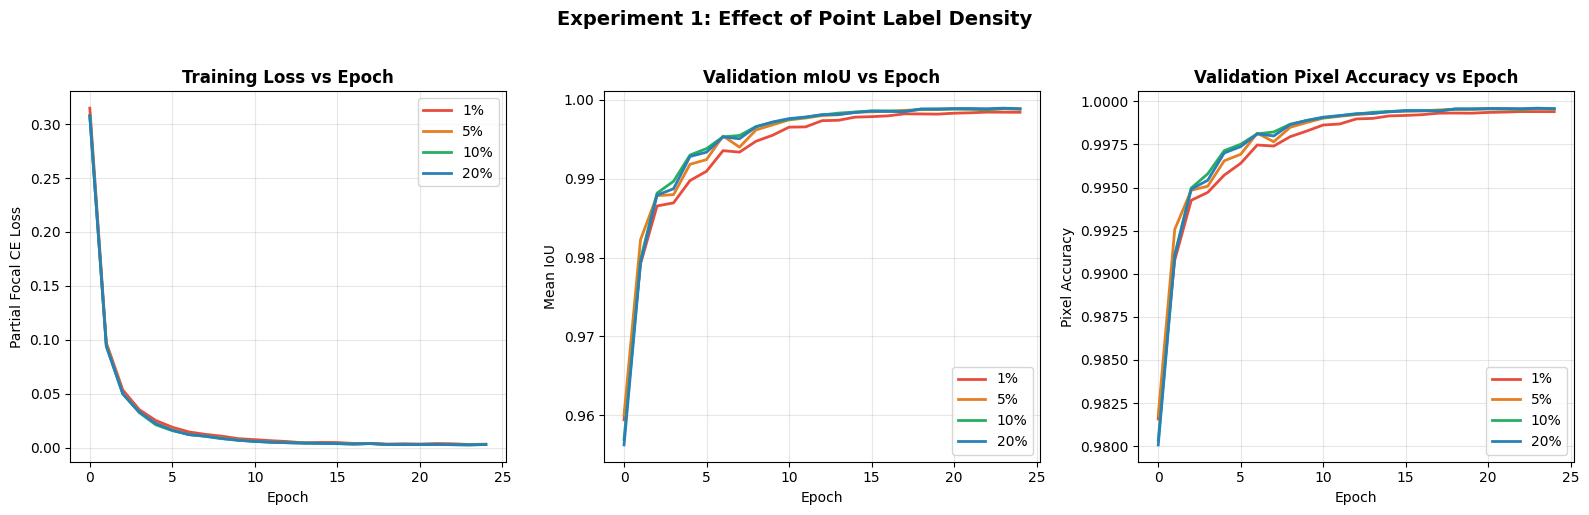

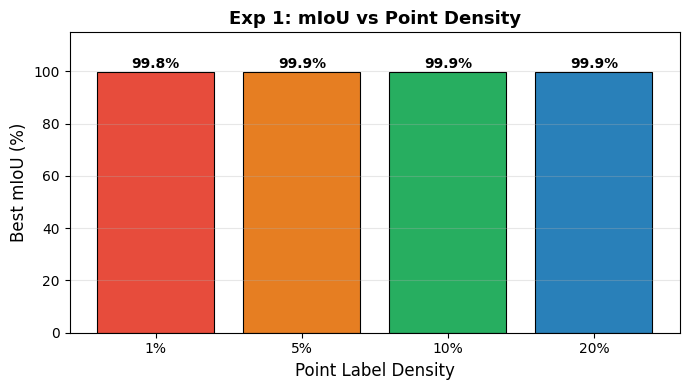

Saved: exp1_point_density.png, exp1_bar.png


In [8]:
# Plot Experiment 1
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']

for i, (label, result) in enumerate(exp1_results.items()):
    h = result['history']
    axes[0].plot(h['train_loss'], label=label, color=colors[i], linewidth=2)
    axes[1].plot(h['val_miou'],   label=label, color=colors[i], linewidth=2)
    axes[2].plot(h['val_acc'],    label=label, color=colors[i], linewidth=2)

axes[0].set_title('Training Loss vs Epoch', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Partial Focal CE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation mIoU vs Epoch', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean IoU')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].set_title('Validation Pixel Accuracy vs Epoch', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Pixel Accuracy')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Experiment 1: Effect of Point Label Density', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp1_point_density.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
labels  = list(exp1_results.keys())
mious   = [exp1_results[l]['best_miou'] * 100 for l in labels]
bars    = ax.bar(labels, mious, color=colors, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, mious):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Point Label Density', fontsize=12)
ax.set_ylabel('Best mIoU (%)', fontsize=12)
ax.set_title('Exp 1: mIoU vs Point Density', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(mious)*1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('exp1_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp1_point_density.png, exp1_bar.png')

---
# EXPERIMENT 2: Effect of Focal Loss Gamma (γ)

**Hypothesis:** Focal loss (γ > 0) improves performance over standard CE (γ=0) by focusing on hard examples.

**Method:** Train with γ = 0, 1, 2, 5 (fixed density=5%, depth=3).

**Expected:** γ=2 or γ=1 optimal; γ=5 may over-focus and degrade performance.

In [9]:
print('=' * 60)
print('EXPERIMENT 2: Focal Loss Gamma (γ)')
print('=' * 60)

gammas      = [0, 1, 2, 5]
exp2_results = {}

for g in gammas:
    label = f'γ={g}'
    loss_name = 'Standard CE' if g == 0 else f'Focal (γ={g})'
    print(f'\n--- {label}: {loss_name} ---')
    config = {
        'point_density'  : 0.05,
        'gamma'          : float(g),
        'depth'          : 3,
        'epochs'         : EPOCHS,
        'lr'             : LR,
        'semi_supervised': False
    }
    result = train_model(config, verbose=True)
    exp2_results[label] = result

print('\n' + '='*60)
print('EXPERIMENT 2 SUMMARY')
print('='*60)
print(f'{"Gamma":>8} | {"Best mIoU":>10} | {"Final Acc":>10}')
print('-' * 36)
for k, v in exp2_results.items():
    print(f'{k:>8} | {v["best_miou"]*100:>9.2f}% | {v["final_acc"]*100:>9.2f}%')

EXPERIMENT 2: Focal Loss Gamma (γ)

--- γ=0: Standard CE ---
  Epoch [  5/25] Train Loss: 0.1343 | Val Loss: 0.1172 | Val Acc: 99.66% | Val mIoU: 99.17%
  Epoch [ 10/25] Train Loss: 0.0451 | Val Loss: 0.0367 | Val Acc: 99.91% | Val mIoU: 99.75%
  Epoch [ 15/25] Train Loss: 0.0267 | Val Loss: 0.0253 | Val Acc: 99.96% | Val mIoU: 99.89%
  Epoch [ 20/25] Train Loss: 0.0202 | Val Loss: 0.0182 | Val Acc: 99.97% | Val mIoU: 99.91%
  Epoch [ 25/25] Train Loss: 0.0197 | Val Loss: 0.0178 | Val Acc: 99.97% | Val mIoU: 99.91%

--- γ=1: Focal (γ=1) ---
  Epoch [  5/25] Train Loss: 0.0453 | Val Loss: 0.0385 | Val Acc: 99.69% | Val mIoU: 99.23%
  Epoch [ 10/25] Train Loss: 0.0145 | Val Loss: 0.0103 | Val Acc: 99.90% | Val mIoU: 99.73%
  Epoch [ 15/25] Train Loss: 0.0084 | Val Loss: 0.0071 | Val Acc: 99.95% | Val mIoU: 99.87%
  Epoch [ 20/25] Train Loss: 0.0060 | Val Loss: 0.0052 | Val Acc: 99.96% | Val mIoU: 99.89%
  Epoch [ 25/25] Train Loss: 0.0061 | Val Loss: 0.0052 | Val Acc: 99.96% | Val mIoU: 

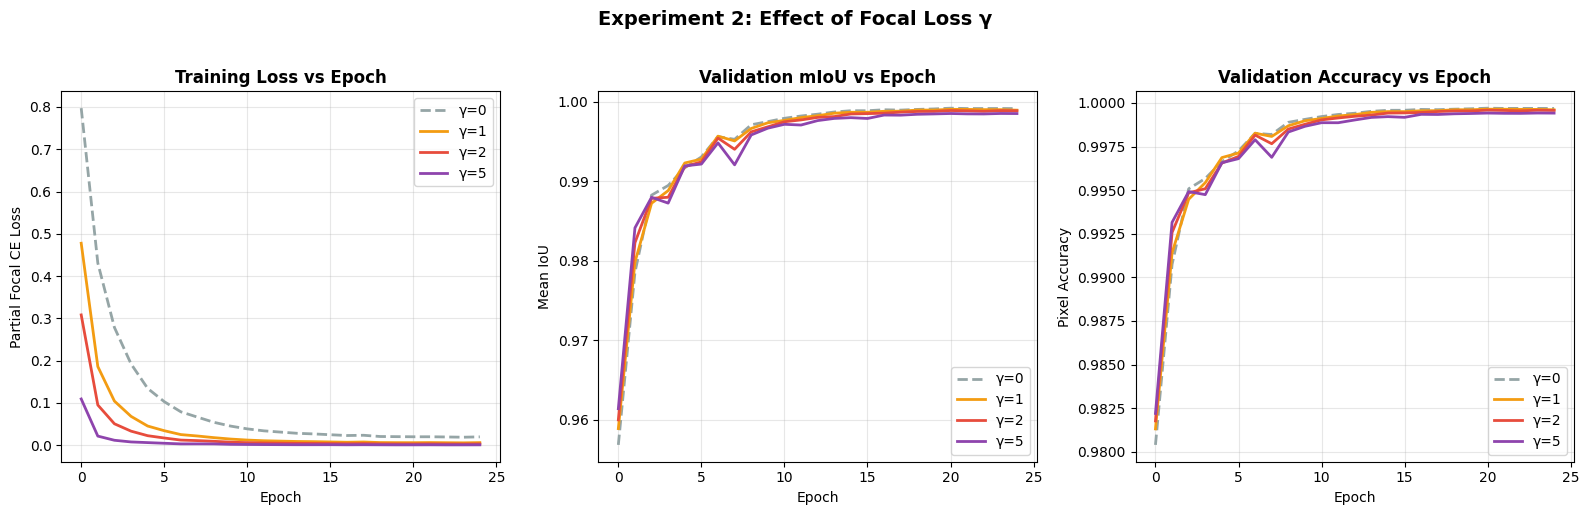

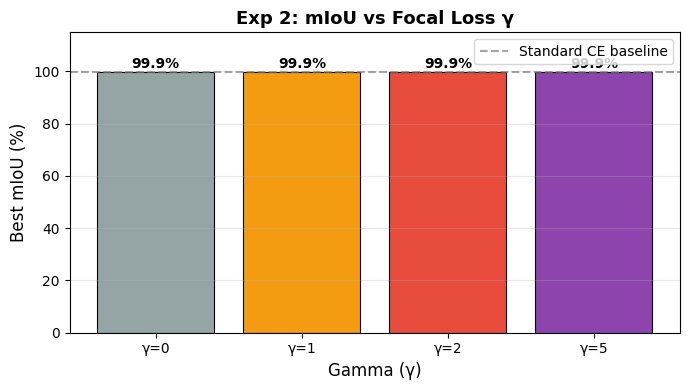

Saved: exp2_gamma.png, exp2_bar.png


In [10]:
# Plot Experiment 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors2 = ['#95a5a6', '#f39c12', '#e74c3c', '#8e44ad']

for i, (label, result) in enumerate(exp2_results.items()):
    h = result['history']
    ls = '--' if i == 0 else '-'
    axes[0].plot(h['train_loss'], label=label, color=colors2[i], linewidth=2, linestyle=ls)
    axes[1].plot(h['val_miou'],   label=label, color=colors2[i], linewidth=2, linestyle=ls)
    axes[2].plot(h['val_acc'],    label=label, color=colors2[i], linewidth=2, linestyle=ls)

for ax, title, ylabel in zip(axes,
    ['Training Loss vs Epoch', 'Validation mIoU vs Epoch', 'Validation Accuracy vs Epoch'],
    ['Partial Focal CE Loss', 'Mean IoU', 'Pixel Accuracy']):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Experiment 2: Effect of Focal Loss γ', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp2_gamma.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
labels2 = list(exp2_results.keys())
mious2  = [exp2_results[l]['best_miou']*100 for l in labels2]
bars2   = ax.bar(labels2, mious2, color=colors2, edgecolor='black', linewidth=0.8)
ax.axhline(mious2[0], color='gray', linestyle='--', alpha=0.7, label='Standard CE baseline')
for bar, v in zip(bars2, mious2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Gamma (γ)', fontsize=12)
ax.set_ylabel('Best mIoU (%)', fontsize=12)
ax.set_title('Exp 2: mIoU vs Focal Loss γ', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(mious2)*1.15)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('exp2_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp2_gamma.png, exp2_bar.png')

---
# EXPERIMENT 3: Network Depth (Shallow vs Deep U-Net)

**Hypothesis:** Deeper U-Net captures richer spatial hierarchies → better mIoU on remote sensing data.

**Method:** Compare U-Net depth=2 vs depth=3 (fixed gamma=2, density=5%).

**Expected:** Depth=3 outperforms, but may be slower to converge.

In [11]:
print('=' * 60)
print('EXPERIMENT 3: Network Depth (Shallow vs Deep)')
print('=' * 60)

depths      = [2, 3]
depth_names = {2: 'Shallow (depth=2)', 3: 'Deep (depth=3)'}
exp3_results = {}

for d in depths:
    label = depth_names[d]
    params = count_params(UNet(depth=d))
    print(f'\n--- {label} | Parameters: {params:,} ---')
    config = {
        'point_density'  : 0.05,
        'gamma'          : 2.0,
        'depth'          : d,
        'epochs'         : EPOCHS,
        'lr'             : LR,
        'semi_supervised': False
    }
    result = train_model(config, verbose=True)
    exp3_results[label] = result

print('\n' + '='*60)
print('EXPERIMENT 3 SUMMARY')
print('='*60)
print(f'{"Model":>25} | {"Params":>10} | {"Best mIoU":>10} | {"Final Acc":>10}')
print('-' * 65)
for d, label in depth_names.items():
    v = exp3_results[label]
    p = count_params(UNet(depth=d))
    print(f'{label:>25} | {p:>10,} | {v["best_miou"]*100:>9.2f}% | {v["final_acc"]*100:>9.2f}%')

EXPERIMENT 3: Network Depth (Shallow vs Deep)

--- Shallow (depth=2) | Parameters: 467,334 ---
  Epoch [  5/25] Train Loss: 0.0256 | Val Loss: 0.0179 | Val Acc: 99.68% | Val mIoU: 99.22%
  Epoch [ 10/25] Train Loss: 0.0074 | Val Loss: 0.0058 | Val Acc: 99.88% | Val mIoU: 99.68%
  Epoch [ 15/25] Train Loss: 0.0045 | Val Loss: 0.0032 | Val Acc: 99.93% | Val mIoU: 99.83%
  Epoch [ 20/25] Train Loss: 0.0035 | Val Loss: 0.0026 | Val Acc: 99.94% | Val mIoU: 99.85%
  Epoch [ 25/25] Train Loss: 0.0033 | Val Loss: 0.0028 | Val Acc: 99.95% | Val mIoU: 99.87%

--- Deep (depth=3) | Parameters: 1,927,174 ---
  Epoch [  5/25] Train Loss: 0.0225 | Val Loss: 0.0238 | Val Acc: 99.66% | Val mIoU: 99.18%
  Epoch [ 10/25] Train Loss: 0.0072 | Val Loss: 0.0047 | Val Acc: 99.88% | Val mIoU: 99.68%
  Epoch [ 15/25] Train Loss: 0.0041 | Val Loss: 0.0034 | Val Acc: 99.94% | Val mIoU: 99.84%
  Epoch [ 20/25] Train Loss: 0.0029 | Val Loss: 0.0024 | Val Acc: 99.95% | Val mIoU: 99.88%
  Epoch [ 25/25] Train Loss: 

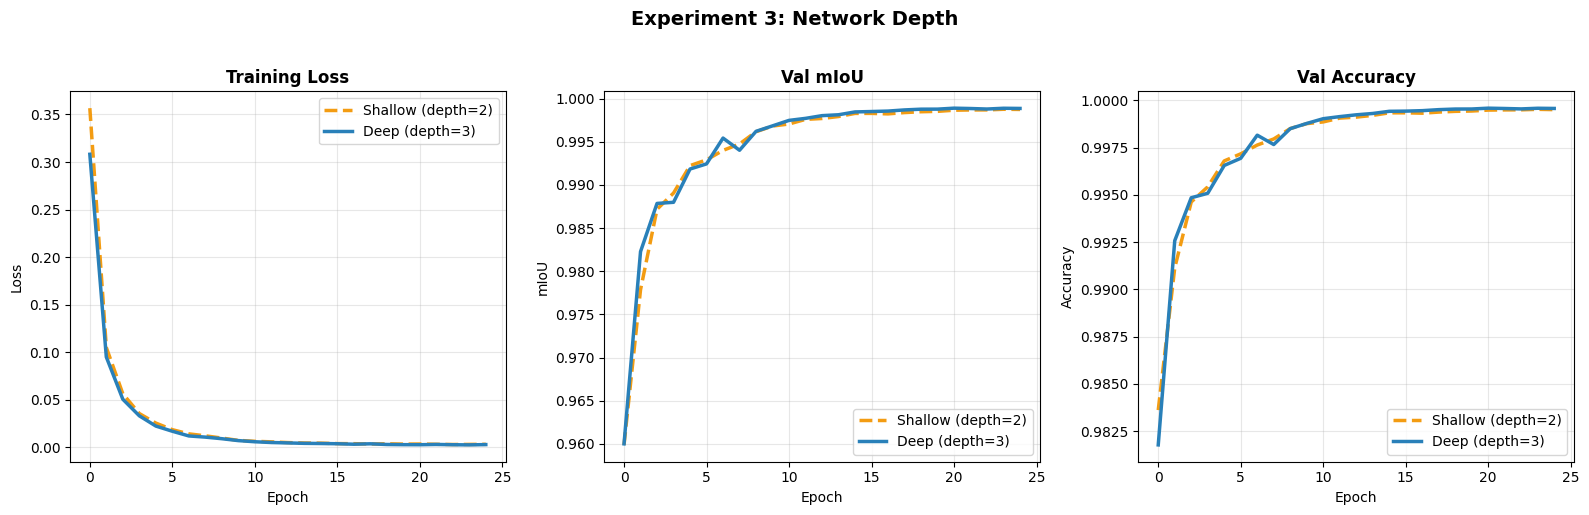

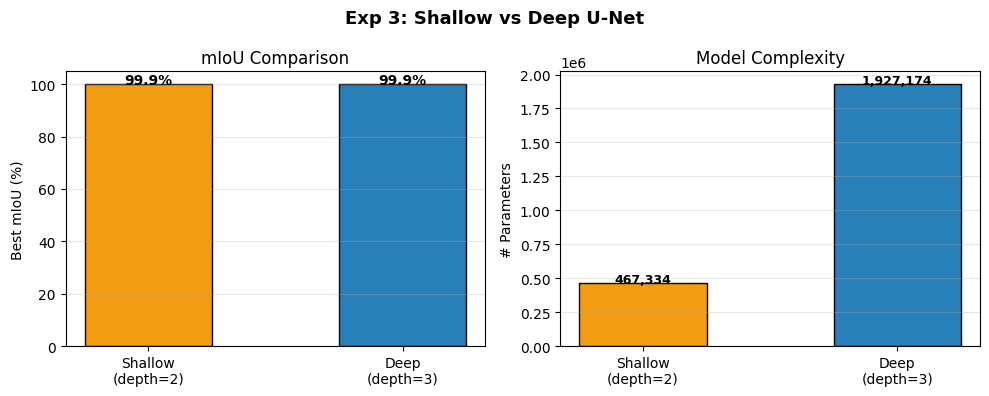

Saved: exp3_depth.png, exp3_bar.png


In [12]:
# Plot Experiment 3
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors3 = ['#f39c12', '#2980b9']
styles  = ['--', '-']

for i, (label, result) in enumerate(exp3_results.items()):
    h = result['history']
    axes[0].plot(h['train_loss'], label=label, color=colors3[i], linewidth=2.5, linestyle=styles[i])
    axes[1].plot(h['val_miou'],   label=label, color=colors3[i], linewidth=2.5, linestyle=styles[i])
    axes[2].plot(h['val_acc'],    label=label, color=colors3[i], linewidth=2.5, linestyle=styles[i])

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Val mIoU', 'Val Accuracy'],
    ['Loss', 'mIoU', 'Accuracy']):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Experiment 3: Network Depth', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp3_depth.png', dpi=150, bbox_inches='tight')
plt.show()

# Side-by-side comparison bar
labels3 = ['Shallow\n(depth=2)', 'Deep\n(depth=3)']
mious3  = [exp3_results[v]['best_miou']*100 for v in exp3_results]
params3 = [count_params(UNet(depth=d)) for d in depths]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
bars3a = ax1.bar(labels3, mious3, color=colors3, edgecolor='black', width=0.5)
for bar, v in zip(bars3a, mious3):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
             ha='center', fontweight='bold')
ax1.set_ylabel('Best mIoU (%)'); ax1.set_title('mIoU Comparison'); ax1.grid(axis='y', alpha=0.3)

bars3b = ax2.bar(labels3, params3, color=colors3, edgecolor='black', width=0.5)
for bar, v in zip(bars3b, params3):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{v:,}',
             ha='center', fontweight='bold', fontsize=9)
ax2.set_ylabel('# Parameters'); ax2.set_title('Model Complexity'); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Exp 3: Shallow vs Deep U-Net', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('exp3_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp3_depth.png, exp3_bar.png')

---
# EXPERIMENT 4: Semi-Supervised Learning (With vs Without Pseudo-Labels)

**Hypothesis:** Incorporating high-confidence pseudo-labels for unlabeled pixels improves mIoU beyond supervised-only training.

**Method:** Compare supervised-only vs semi-supervised (pseudo-labels with confidence > 0.85 added from epoch 5 onward).

**Expected:** Semi-supervised significantly boosts mIoU since ~95% of pixels are unlabeled.

In [19]:
print('=' * 60)
print('EXPERIMENT 4: Semi-Supervised Learning')
print('=' * 60)

exp4_results = {}

for semi in [False, True]:
    label = 'Semi-Supervised' if semi else 'Supervised Only'
    print(f'\n--- {label} ---')
    config = {
        'point_density'  : 0.05,
        'gamma'          : 2.0,
        'depth'          : 3,
        'epochs'         : EPOCHS,
        'lr'             : LR,
        'semi_supervised': semi
    }
    result = train_model(config, verbose=True)
    exp4_results[label] = result

print('\n' + '='*60)
print('EXPERIMENT 4 SUMMARY')
print('='*60)
print(f'{"Method":>20} | {"Best mIoU":>10} | {"Final Acc":>10}')
print('-' * 46)
for k, v in exp4_results.items():
    print(f'{k:>20} | {v["best_miou"]*100:>9.2f}% | {v["final_acc"]*100:>9.2f}%')

EXPERIMENT 4: Semi-Supervised Learning

--- Supervised Only ---
  Epoch [  5/25] Train Loss: 0.0225 | Val Loss: 0.0238 | Val Acc: 99.66% | Val mIoU: 99.18%
  Epoch [ 10/25] Train Loss: 0.0072 | Val Loss: 0.0047 | Val Acc: 99.88% | Val mIoU: 99.68%
  Epoch [ 15/25] Train Loss: 0.0041 | Val Loss: 0.0034 | Val Acc: 99.94% | Val mIoU: 99.84%
  Epoch [ 20/25] Train Loss: 0.0029 | Val Loss: 0.0024 | Val Acc: 99.95% | Val mIoU: 99.88%
  Epoch [ 25/25] Train Loss: 0.0030 | Val Loss: 0.0024 | Val Acc: 99.96% | Val mIoU: 99.89%

--- Semi-Supervised ---
  Epoch [  5/25] Train Loss: 0.0225 | Val Loss: 0.0238 | Val Acc: 99.66% | Val mIoU: 99.18%
  Epoch [ 10/25] Train Loss: 0.0064 | Val Loss: 0.0037 | Val Acc: 99.87% | Val mIoU: 99.67%
  Epoch [ 15/25] Train Loss: 0.0029 | Val Loss: 0.0018 | Val Acc: 99.95% | Val mIoU: 99.86%
  Epoch [ 20/25] Train Loss: 0.0018 | Val Loss: 0.0013 | Val Acc: 99.97% | Val mIoU: 99.91%
  Epoch [ 25/25] Train Loss: 0.0019 | Val Loss: 0.0013 | Val Acc: 99.97% | Val mIoU

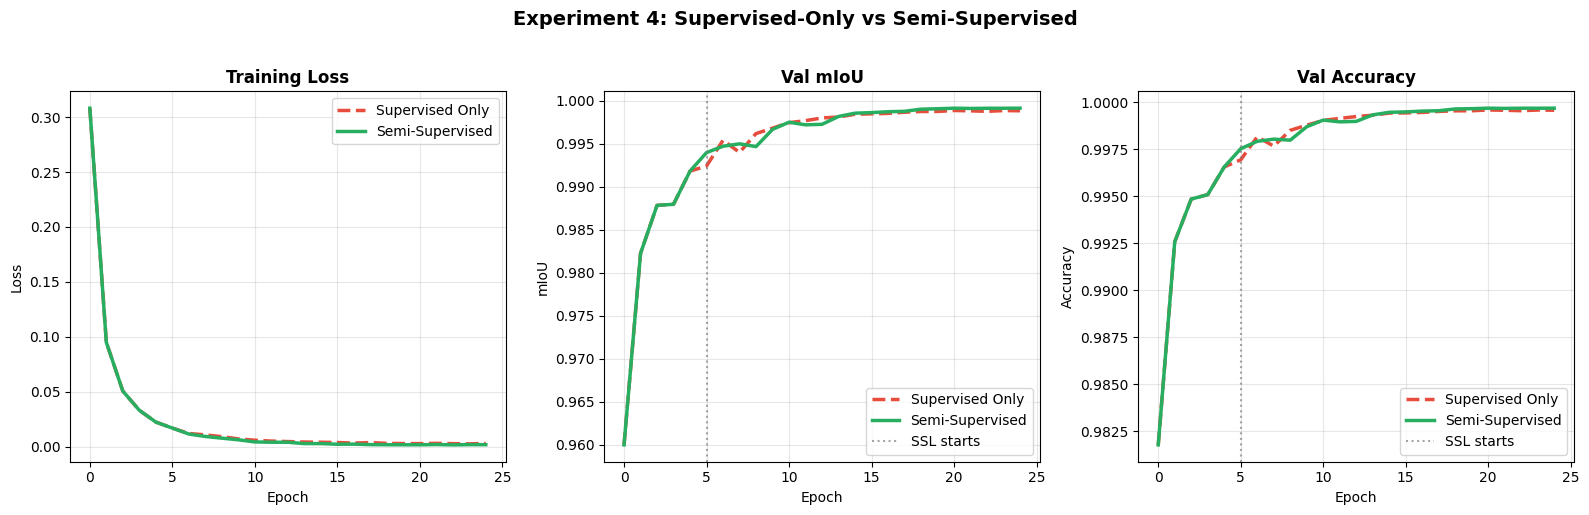

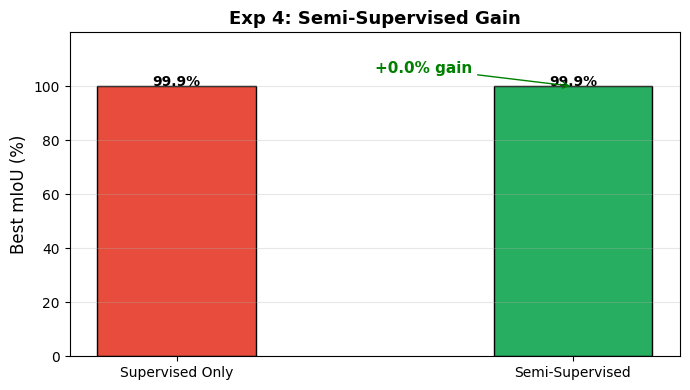

Saved: exp4_semi.png, exp4_bar.png


In [20]:
# Plot Experiment 4
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors4 = ['#e74c3c', '#27ae60']
styles4 = ['--', '-']

for i, (label, result) in enumerate(exp4_results.items()):
    h = result['history']
    axes[0].plot(h['train_loss'], label=label, color=colors4[i], linewidth=2.5, linestyle=styles4[i])
    axes[1].plot(h['val_miou'],   label=label, color=colors4[i], linewidth=2.5, linestyle=styles4[i])
    axes[2].plot(h['val_acc'],    label=label, color=colors4[i], linewidth=2.5, linestyle=styles4[i])

for ax in axes[1:]:
    ax.axvline(x=5, color='gray', linestyle=':', alpha=0.7, label='SSL starts')
    ax.legend()

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Val mIoU', 'Val Accuracy'],
    ['Loss', 'mIoU', 'Accuracy']):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Experiment 4: Supervised-Only vs Semi-Supervised', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exp4_semi.png', dpi=150, bbox_inches='tight')
plt.show()

labels4 = list(exp4_results.keys())
mious4  = [exp4_results[l]['best_miou']*100 for l in labels4]
gain    = mious4[1] - mious4[0]

fig, ax = plt.subplots(figsize=(7, 4))
bars4 = ax.bar(labels4, mious4, color=colors4, edgecolor='black', width=0.4)
for bar, v in zip(bars4, mious4):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
            ha='center', fontweight='bold')
ax.annotate(f'+{gain:.1f}% gain', xy=(1, mious4[1]), xytext=(0.5, max(mious4)*1.05),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontweight='bold', fontsize=11)
ax.set_ylabel('Best mIoU (%)', fontsize=12)
ax.set_title('Exp 4: Semi-Supervised Gain', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(mious4)*1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('exp4_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp4_semi.png, exp4_bar.png')

---
 Qualitative Visualisation — Prediction Examples

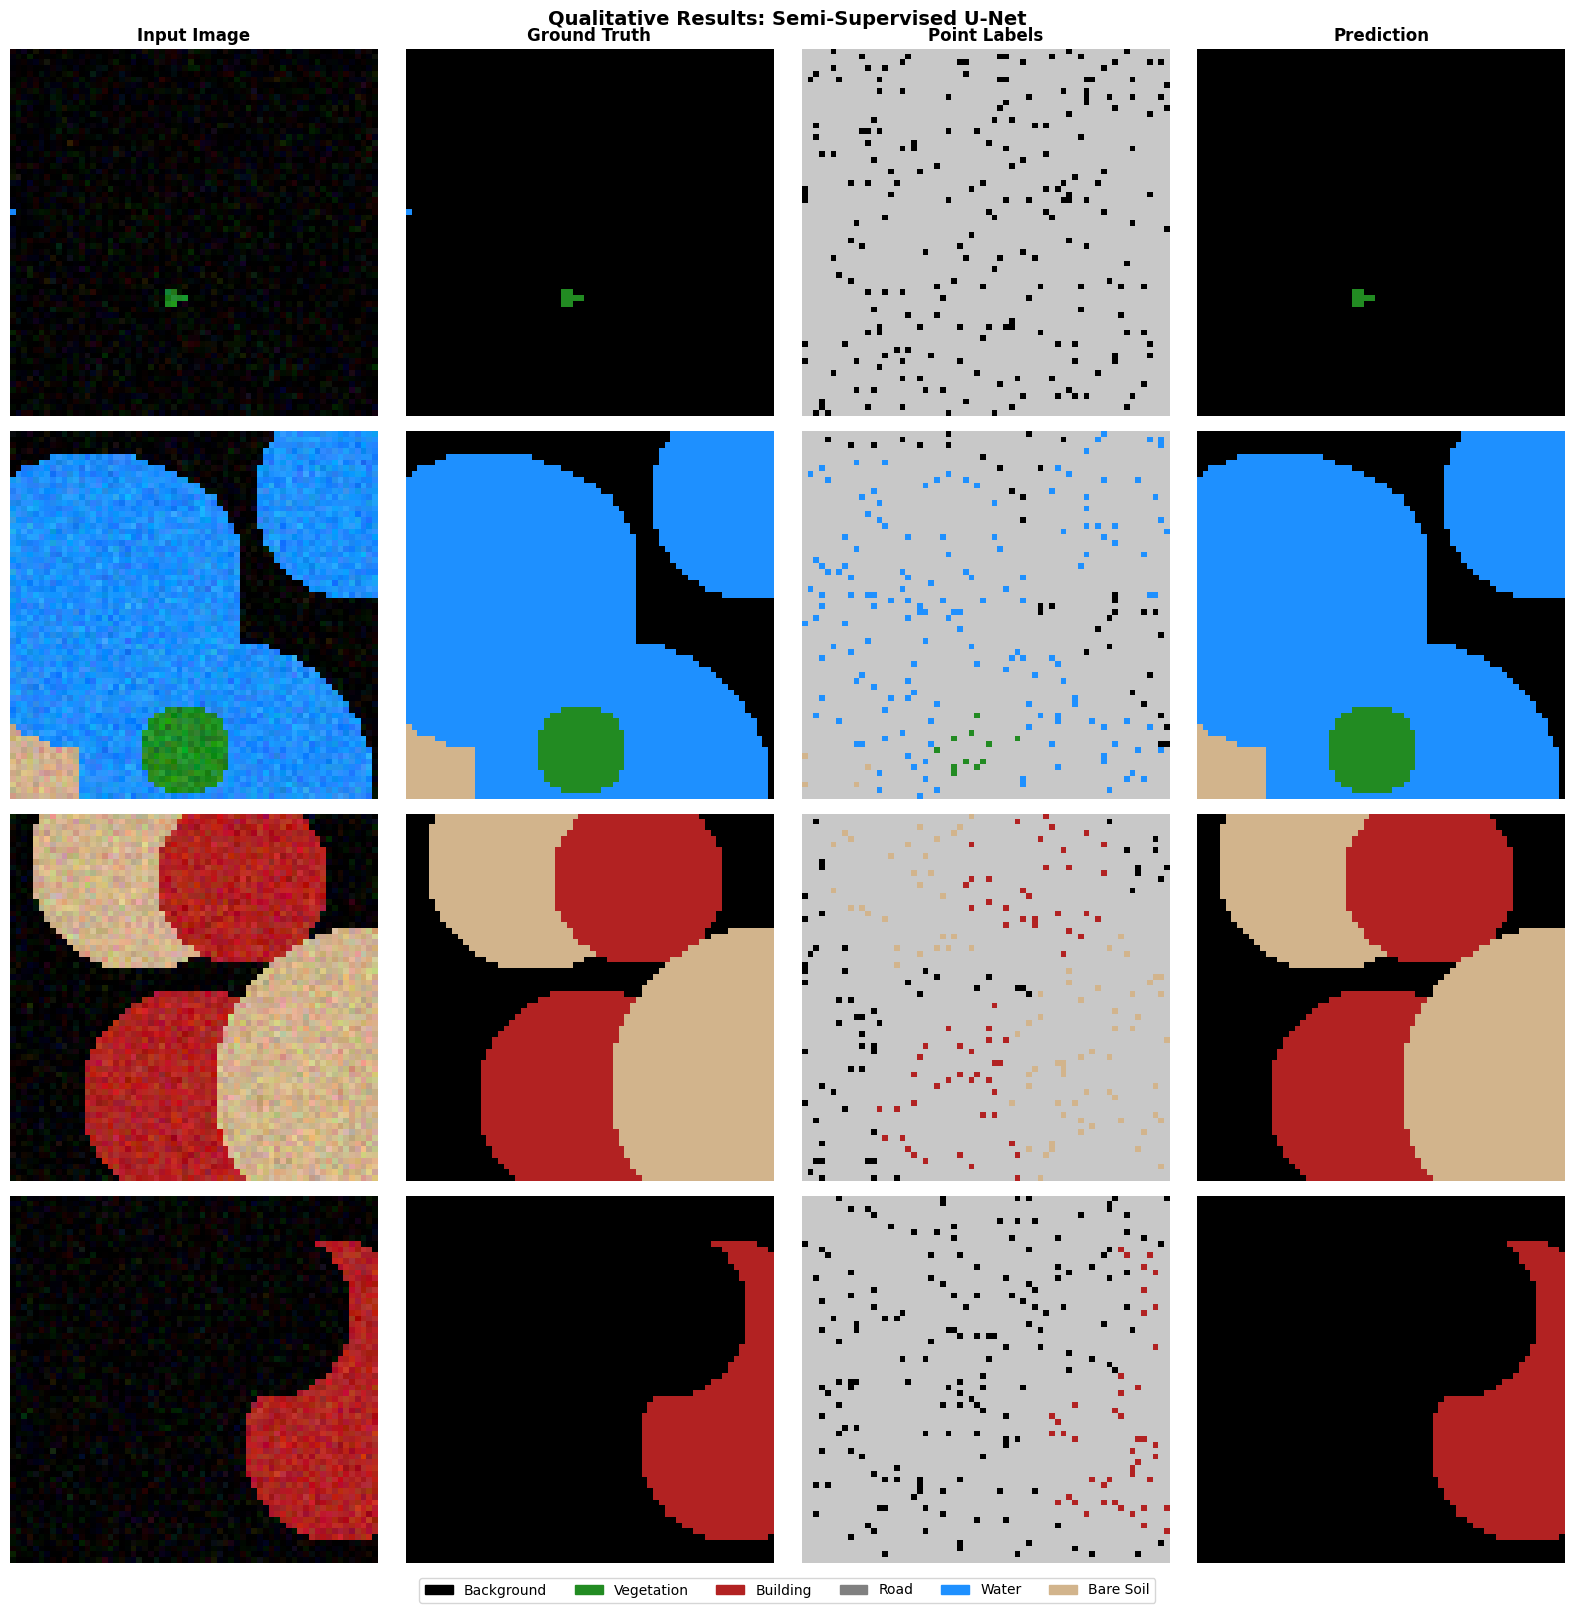

Saved: predictions.png


In [21]:
@torch.no_grad()
def visualise_predictions(model, dataset, n=4, title='Predictions'):
    model.eval()
    normalize_inv = transforms.Compose([
        transforms.Normalize(mean=[0, 0, 0], std=[1/0.229, 1/0.224, 1/0.225]),
        transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1, 1, 1]),
    ])

    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    col_titles = ['Input Image', 'Ground Truth', 'Point Labels', 'Prediction']
    for j, ct in enumerate(col_titles):
        axes[0, j].set_title(ct, fontsize=12, fontweight='bold')

    for i in range(n):
        img_t, mask_t, point_t = dataset[i]
        img_vis = normalize_inv(img_t).permute(1, 2, 0).numpy().clip(0, 1)

        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        pt = point_t.numpy()
        pt_vis = np.ones((*pt.shape, 3), dtype=np.uint8) * 200
        pt_vis[pt >= 0] = CLASS_COLORS[pt[pt >= 0]]

        axes[i, 0].imshow(img_vis)
        axes[i, 1].imshow(CLASS_COLORS[mask_t.numpy()])
        axes[i, 2].imshow(pt_vis)
        axes[i, 3].imshow(CLASS_COLORS[pred])

        for ax in axes[i]:
            ax.axis('off')

    patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: predictions.png')


best_model = exp4_results['Semi-Supervised']['model']
val_ds_vis = RemoteSensingDataset(NUM_VAL, IMG_SIZE, 0.05, augment=False)
visualise_predictions(best_model, val_ds_vis, n=4, title='Qualitative Results: Semi-Supervised U-Net')

---
 Overall Comparison & Final Technical Report

In [22]:
print('\n' + '='*70)
print('OVERALL EXPERIMENT SUMMARY')
print('='*70)

all_results = []

for label, r in exp1_results.items():
    all_results.append(('Exp 1 - Density', label, r['best_miou']*100, r['final_acc']*100))

for label, r in exp2_results.items():
    all_results.append(('Exp 2 - Gamma', label, r['best_miou']*100, r['final_acc']*100))

for label, r in exp3_results.items():
    all_results.append(('Exp 3 - Depth', label, r['best_miou']*100, r['final_acc']*100))

for label, r in exp4_results.items():
    all_results.append(('Exp 4 - SSL', label, r['best_miou']*100, r['final_acc']*100))

print(f'{"Experiment":>20} | {"Config":>25} | {"Best mIoU":>10} | {"Final Acc":>10}')
print('-' * 76)
prev_exp = ''
for exp, cfg, miou, acc in all_results:
    sep = '\n' if exp != prev_exp and prev_exp != '' else ''
    print(f'{sep}{exp:>20} | {cfg:>25} | {miou:>9.2f}% | {acc:>9.2f}%')
    prev_exp = exp

# Find best config overall
best = max(all_results, key=lambda x: x[2])
print(f'\n🏆 Best Configuration: [{best[0]}] {best[1]} → mIoU = {best[2]:.2f}%')


OVERALL EXPERIMENT SUMMARY
          Experiment |                    Config |  Best mIoU |  Final Acc
----------------------------------------------------------------------------
     Exp 1 - Density |                        1% |     99.85% |     99.94%
     Exp 1 - Density |                        5% |     99.89% |     99.96%
     Exp 1 - Density |                       10% |     99.89% |     99.96%
     Exp 1 - Density |                       20% |     99.90% |     99.96%

       Exp 2 - Gamma |                       γ=0 |     99.92% |     99.97%
       Exp 2 - Gamma |                       γ=1 |     99.90% |     99.96%
       Exp 2 - Gamma |                       γ=2 |     99.89% |     99.96%
       Exp 2 - Gamma |                       γ=5 |     99.85% |     99.94%

       Exp 3 - Depth |         Shallow (depth=2) |     99.88% |     99.95%
       Exp 3 - Depth |            Deep (depth=3) |     99.89% |     99.96%

         Exp 4 - SSL |           Supervised Only |     99.89% |    

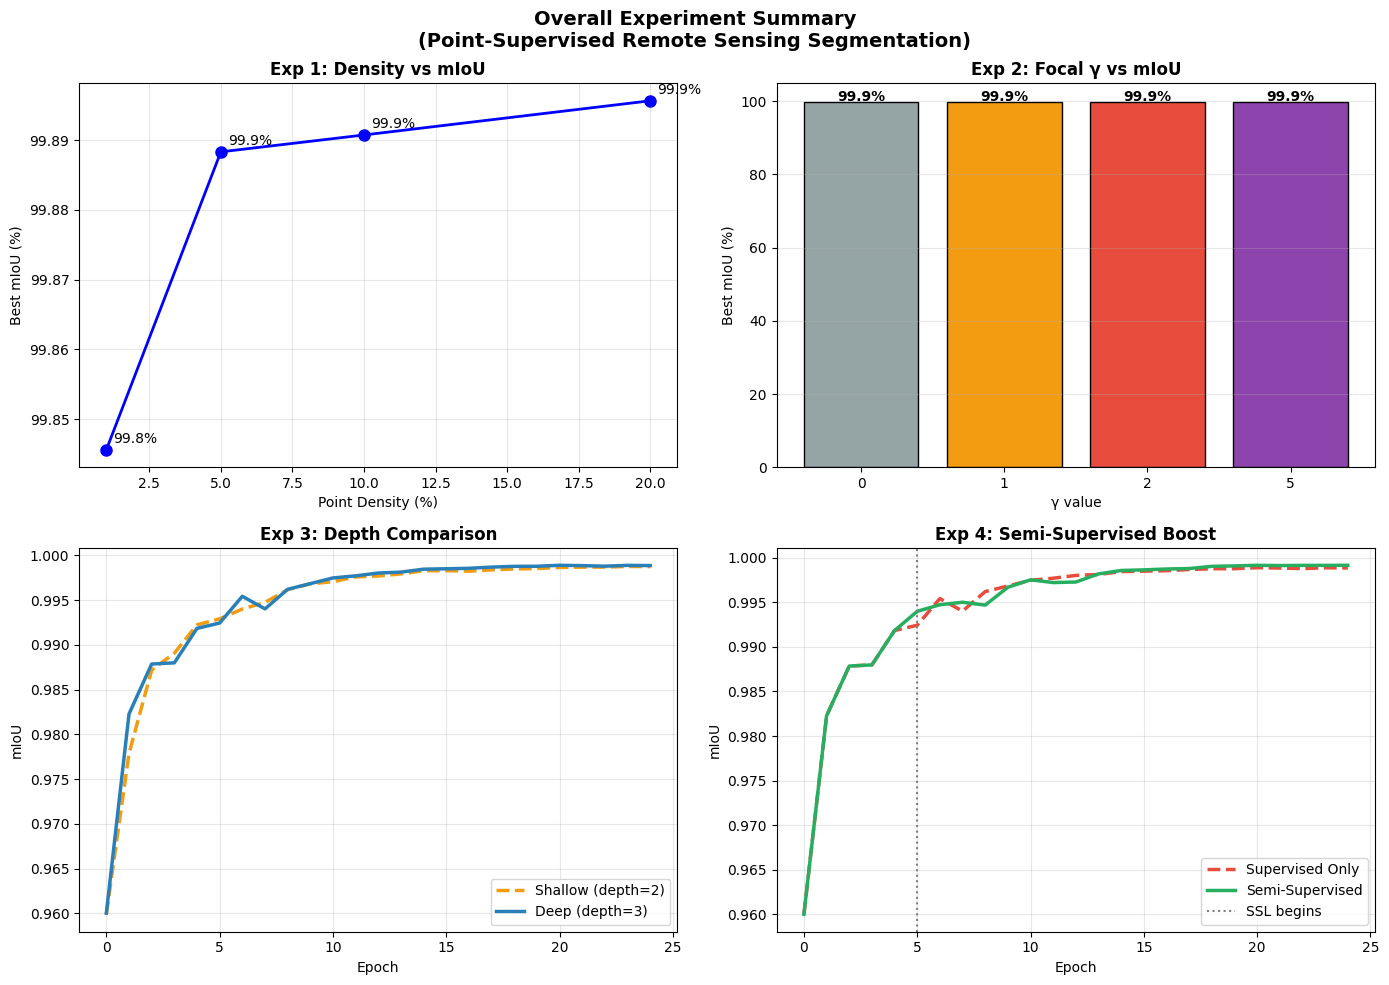

Saved: overall_summary.png


In [23]:
# Final summary figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Exp1 summary
ax = axes[0, 0]
x1 = [1, 5, 10, 20]
y1 = [exp1_results[f'{d}%']['best_miou']*100 for d in x1]
ax.plot(x1, y1, 'bo-', linewidth=2, markersize=8)
for xi, yi in zip(x1, y1):
    ax.annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points', xytext=(5, 5))
ax.set_xlabel('Point Density (%)'); ax.set_ylabel('Best mIoU (%)')
ax.set_title('Exp 1: Density vs mIoU', fontweight='bold')
ax.grid(alpha=0.3)

# Exp2 summary
ax = axes[0, 1]
x2 = [0, 1, 2, 5]
y2 = [exp2_results[f'γ={g}']['best_miou']*100 for g in x2]
ax.bar([str(g) for g in x2], y2, color=['#95a5a6','#f39c12','#e74c3c','#8e44ad'],
       edgecolor='black')
for xi, yi in zip(range(len(x2)), y2):
    ax.text(xi, yi+0.2, f'{yi:.1f}%', ha='center', fontweight='bold')
ax.set_xlabel('γ value'); ax.set_ylabel('Best mIoU (%)')
ax.set_title('Exp 2: Focal γ vs mIoU', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Exp3 summary
ax = axes[1, 0]
for i, (label, result) in enumerate(exp3_results.items()):
    ax.plot(result['history']['val_miou'], label=label,
            color=['#f39c12','#2980b9'][i], linewidth=2.5,
            linestyle=['--','-'][i])
ax.set_xlabel('Epoch'); ax.set_ylabel('mIoU')
ax.set_title('Exp 3: Depth Comparison', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Exp4 summary
ax = axes[1, 1]
for i, (label, result) in enumerate(exp4_results.items()):
    ax.plot(result['history']['val_miou'], label=label,
            color=['#e74c3c','#27ae60'][i], linewidth=2.5,
            linestyle=['--','-'][i])
ax.axvline(5, color='gray', linestyle=':', label='SSL begins')
ax.set_xlabel('Epoch'); ax.set_ylabel('mIoU')
ax.set_title('Exp 4: Semi-Supervised Boost', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Overall Experiment Summary\n(Point-Supervised Remote Sensing Segmentation)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('overall_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: overall_summary.png')